## task:0 
## Connect DuckDB 


In [144]:
import duckdb
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

duckdb_path = "data/sakila.duckdb"
Path(duckdb_path).unlink(missing_ok=True)

with duckdb.connect(duckdb_path) as conn, open("sql/load_sakila_sqlite.sql") as ingest_script:
    conn.sql(ingest_script.read())

    description = conn.sql("DESC;").df()
    films = conn.sql("FROM film;").df()

films.head(3)

,film_id,title,description,release_year,language_id,original_language_id,rental_duration,rental_rate,length,replacement_cost,rating,special_features,last_update
0,1,ACADEMY DINOSAUR,A Epic Drama of a Feminist And a Mad Scientist...,2006,1,<NA>,6,0.99,86,20.99,PG,"Deleted Scenes,Behind the Scenes",2021-03-06 15:52:00
1,2,ACE GOLDFINGER,A Astounding Epistle of a Database Administrat...,2006,1,<NA>,3,4.99,48,12.99,G,"Trailers,Deleted Scenes",2021-03-06 15:52:00
2,3,ADAPTATION HOLES,A Astounding Reflection of a Lumberjack And a ...,2006,1,<NA>,7,2.99,50,18.99,NC-17,"Trailers,Deleted Scenes",2021-03-06 15:52:00


In [145]:
description.head()

,database,schema,name,column_names,column_types,temporary
0,sakila,main,actor,"[actor_id, first_name, last_name, last_update]","[DOUBLE, VARCHAR, VARCHAR, TIMESTAMP]",False
1,sakila,main,address,"[address_id, address, address2, district, city...","[BIGINT, VARCHAR, VARCHAR, VARCHAR, BIGINT, VA...",False
2,sakila,main,category,"[category_id, name, last_update]","[BIGINT, VARCHAR, TIMESTAMP]",False
3,sakila,main,city,"[city_id, city, country_id, last_update]","[BIGINT, VARCHAR, BIGINT, TIMESTAMP]",False
4,sakila,main,country,"[country_id, country, last_update]","[BIGINT, VARCHAR, TIMESTAMP]",False


## Some code from lecture 18 as help to read in all data into dictionary of panda DataFrames 

In [146]:
dfs = {}

with duckdb.connect(duckdb_path) as conn:
    for name in description["name"]:
        dfs[name] = conn.sql(f"FROM {name};").df()

dfs.keys()

dict_keys(['actor', 'address', 'category', 'city', 'country', 'customer', 'customer_list', 'film', 'film_actor', 'film_category', 'film_list', 'film_text', 'inventory', 'language', 'payment', 'rental', 'sales_by_film_category', 'sales_by_store', 'staff', 'staff_list', 'store'])

In [147]:
dfs["film_actor"].head(200)

,actor_id,film_id,last_update
0,1,1,2021-03-06 15:52:45
1,1,23,2021-03-06 15:52:45
2,1,25,2021-03-06 15:52:45
3,1,106,2021-03-06 15:52:45
4,1,140,2021-03-06 15:52:45
...,...,...,...
195,9,510,2021-03-06 15:52:46
196,9,514,2021-03-06 15:52:46
197,9,552,2021-03-06 15:52:46
198,9,650,2021-03-06 15:52:46


##  Time to register all data in duckdb, referens from lecture 18. 

In [148]:
tbl_names = ('actor', 'address', 'category', 'city', 'country', 'customer', 
              'customer_list','film', 'film_actor', 'film_category', 'film_list', 
              'film_text', 'inventory', 'language', 'payment', 'rental', 
              'sales_by_film_category', 'sales_by_store', 'staff', 'staff_list', 'store')

for tbl_name in tbl_names:
    duckdb.register(tbl_name, dfs[tbl_name])

duckdb.sql("desc;").df()

,database,schema,name,column_names,column_types,temporary
0,temp,main,actor,"[actor_id, first_name, last_name, last_update]","[DOUBLE, VARCHAR, VARCHAR, TIMESTAMP]",True
1,temp,main,address,"[address_id, address, address2, district, city...","[BIGINT, VARCHAR, ""NULL"", VARCHAR, BIGINT, VAR...",True
2,temp,main,category,"[category_id, name, last_update]","[BIGINT, VARCHAR, TIMESTAMP]",True
3,temp,main,city,"[city_id, city, country_id, last_update]","[BIGINT, VARCHAR, BIGINT, TIMESTAMP]",True
4,temp,main,country,"[country_id, country, last_update]","[BIGINT, VARCHAR, TIMESTAMP]",True
5,temp,main,customer,"[customer_id, store_id, first_name, last_name,...","[BIGINT, BIGINT, VARCHAR, VARCHAR, VARCHAR, BI...",True
6,temp,main,customer_list,"[ID, name, address, zip_code, phone, city, cou...","[BIGINT, VARCHAR, VARCHAR, VARCHAR, VARCHAR, V...",True
7,temp,main,film,"[film_id, title, description, release_year, la...","[BIGINT, VARCHAR, VARCHAR, VARCHAR, BIGINT, BI...",True
8,temp,main,film_actor,"[actor_id, film_id, last_update]","[BIGINT, BIGINT, TIMESTAMP]",True
9,temp,main,film_category,"[film_id, category_id, last_update]","[BIGINT, BIGINT, TIMESTAMP]",True


## lets start with task: 1 

#### a) which movies are longer than 180 min or 3 hours, show the title and the actual length?


In [149]:
# The data are allready registred so, its time to just query them. 
longest_film = duckdb.sql("""   
     select 
        title,
        length
    from 
        film 
   Where
        length > 180
                          
    order by length desc
                          
""").df()
longest_film

,title,length
0,WORST BANGER,185
1,CHICAGO NORTH,185
2,CONTROL ANTHEM,185
3,DARN FORRESTER,185
4,SWEET BROTHERHOOD,185
5,GANGS PRIDE,185
6,HOME PITY,185
7,SOLDIERS EVOLUTION,185
8,POND SEATTLE,185
9,MUSCLE BRIGHT,185


### b) witch movies have the word "LOVE" in the title? show the following columns:
- title
- rating 
- length 
- description 


In [150]:
# ILIKE is case insensitive

Word_love = duckdb.sql("""--  
     select 
        title,
        length,
        description,
        rating
    from 
        film 
    Where
        title ILIKE '%love%'  
    order by title asc;
""").df()

Word_love


,title,length,description,rating
0,GRAFFITI LOVE,117,A Unbelieveable Epistle of a Sumo Wrestler And...,PG
1,IDAHO LOVE,172,A Fast-Paced Drama of a Student And a Crocodil...,PG-13
2,IDENTITY LOVER,119,A Boring Tale of a Composer And a Mad Cow who ...,PG-13
3,INDIAN LOVE,135,A Insightful Saga of a Mad Scientist And a Mad...,NC-17
4,LAWRENCE LOVE,175,A Fanciful Yarn of a Database Administrator An...,NC-17
5,LOVE SUICIDES,181,A Brilliant Panorama of a Hunter And a Explore...,R
6,LOVELY JINGLE,65,A Fanciful Yarn of a Crocodile And a Forensic ...,PG
7,LOVER TRUMAN,75,A Emotional Yarn of a Robot And a Boy who must...,G
8,LOVERBOY ATTACKS,162,A Boring Story of a Car And a Butler who must ...,PG-13
9,STRANGELOVE DESIRE,103,A Awe-Inspiring Panorama of a Lumberjack And a...,NC-17


### c) Descriptive statistics on the length column, The Manager wants, shortest, average, median and longest movie length

In [151]:
statistics_lenght  = duckdb.sql("""
    select
        median(length) as median_length,                       
        avg(length) as average_length,
        min(length) as minimum_length,
        max(length) as maximum_length,
                         
    from
        film
""").df()
statistics_lenght                                              


,median_length,average_length,minimum_length,maximum_length
0,114.0,115.272,46,185


### d) The 10 most expensive movies to rent per day? 

In [152]:
duckdb.sql("""
    select    
        title,
        rental_rate,
        rental_duration,
        
    from 
        film;
""").df()

,title,rental_rate,rental_duration
0,ACADEMY DINOSAUR,0.99,6
1,ACE GOLDFINGER,4.99,3
2,ADAPTATION HOLES,2.99,7
3,AFFAIR PREJUDICE,2.99,5
4,AFRICAN EGG,2.99,6
...,...,...,...
995,YOUNG LANGUAGE,0.99,6
996,YOUTH KICK,0.99,4
997,ZHIVAGO CORE,0.99,6
998,ZOOLANDER FICTION,2.99,5


In [153]:
# Calculate the rentale rate per day and show the 100 films with the lowest rate per day. 
mo_ex_ra = duckdb.sql("""
    select    
        title,
        rental_rate,
        rental_duration,
        round (rental_rate / rental_duration, 2) as rate_per_day
                      
    from 
        film 
    order by rate_per_day asc
    limit 100;
                      
    """).df()   
mo_ex_ra               

,title,rental_rate,rental_duration,rate_per_day
0,GHOSTBUSTERS ELF,0.99,7,0.14
1,LIGHTS DEER,0.99,7,0.14
2,EMPIRE MALKOVICH,0.99,7,0.14
3,CARRIE BUNCH,0.99,7,0.14
4,BORROWERS BEDAZZLED,0.99,7,0.14
...,...,...,...,...
95,CONGENIALITY QUEST,0.99,6,0.17
96,CAPER MOTIONS,0.99,6,0.17
97,ALTER VICTORY,0.99,6,0.17
98,OUTBREAK DIVINE,0.99,6,0.17


### Top 10 actors with the number of movies they have played in. 

In [154]:
# showing the actor table 
dfs["actor"]

,actor_id,first_name,last_name,last_update
0,1.0,PENELOPE,GUINESS,2021-03-06 15:51:59
1,2.0,NICK,WAHLBERG,2021-03-06 15:51:59
2,3.0,ED,CHASE,2021-03-06 15:51:59
3,4.0,JENNIFER,DAVIS,2021-03-06 15:51:59
4,5.0,JOHNNY,LOLLOBRIGIDA,2021-03-06 15:51:59
...,...,...,...,...
195,196.0,BELA,WALKEN,2021-03-06 15:52:00
196,197.0,REESE,WEST,2021-03-06 15:52:00
197,198.0,MARY,KEITEL,2021-03-06 15:52:00
198,199.0,JULIA,FAWCETT,2021-03-06 15:52:00


In [155]:
# Top 10 actors who acted in most films, 
# with their film counts,
#  first name, and last name. joining actor and film_actor tables.

top_10_actor = duckdb.sql("""

    SELECT
            a.actor_id,
            a.first_name,
            a.last_name,
            COUNT(fa.film_id) AS film_count
        FROM actor AS a
        JOIN film_actor AS fa
            ON a.actor_id = fa.actor_id
        GROUP BY
            a.actor_id,
            a.first_name,
            a.last_name
        ORDER BY
            film_count DESC
        LIMIT 10;
     
""").df()
top_10_actor

,actor_id,first_name,last_name,film_count
0,107.0,GINA,DEGENERES,42
1,102.0,WALTER,TORN,41
2,198.0,MARY,KEITEL,40
3,181.0,MATTHEW,CARREY,39
4,23.0,SANDRA,KILMER,37
5,81.0,SCARLETT,DAMON,36
6,13.0,UMA,WOOD,35
7,158.0,VIVIEN,BASINGER,35
8,106.0,GROUCHO,DUNST,35
9,144.0,ANGELA,WITHERSPOON,35


### f)3-5 questions

1) how many films are there in total?

In [156]:
firs_question = duckdb.sql("""
   select count(*) as total_films 
    from film;
                           
""").df()
firs_question

,total_films
0,1000


2) Actor sorted alphabetically 

In [157]:
second_question = duckdb.sql("""
    select 
        first_name,
        last_name,
    From actor 
    order by first_name asc , last_name asc 
    limit 20
                            

 """).df()
second_question

,first_name,last_name
0,ADAM,GRANT
1,ADAM,HOPPER
2,AL,GARLAND
3,ALAN,DREYFUSS
4,ALBERT,JOHANSSON
5,ALBERT,NOLTE
6,ALEC,WAYNE
7,ANGELA,HUDSON
8,ANGELA,WITHERSPOON
9,ANGELINA,ASTAIRE


In [158]:
dfs["rental"].head()

,rental_id,rental_date,inventory_id,customer_id,return_date,staff_id,last_update
0,1,2005-05-24 22:53:30,367,130,2005-05-26 22:04:30,1,2021-03-06 15:53:41
1,2,2005-05-24 22:54:33,1525,459,2005-05-28 19:40:33,1,2021-03-06 15:53:41
2,3,2005-05-24 23:03:39,1711,408,2005-06-01 22:12:39,1,2021-03-06 15:53:41
3,4,2005-05-24 23:04:41,2452,333,2005-06-03 01:43:41,2,2021-03-06 15:53:41
4,5,2005-05-24 23:05:21,2079,222,2005-06-02 04:33:21,1,2021-03-06 15:53:41


3) wich movies has a 3_days loan period? 

In [159]:
third_question = duckdb.sql("""
    SELECT COUNT(*) AS movies_3_days
    FROM film
    WHERE rental_duration = 3;
""").df()
third_question 

,movies_3_days
0,203


4) Movies shorter then 60 min. 

In [160]:
fourth_question = duckdb.sql("""
    select 
        title,
        length 
    from film 
    where length < 60 
    order by length asc
    limit 20 
                             
""").df()
fourth_question

,title,length
0,ALIEN CENTER,46
1,KWAI HOMEWARD,46
2,LABYRINTH LEAGUE,46
3,IRON MOON,46
4,RIDGEMONT SUBMARINE,46
5,HANOVER GALAXY,47
6,SHANGHAI TYCOON,47
7,DOWNHILL ENOUGH,47
8,HALLOWEEN NUTS,47
9,SUSPECTS QUILLS,47


5) Movies between 60-120 min 

In [161]:
fourth_question = duckdb.sql("""
    select 
        title,
        length 
    from film 
    where length > 60 and length < 120 
    order by length asc
    limit 500
                             
""").df()
fourth_question

,title,length
0,BIRDS PERDITION,61
1,CASSIDY WYOMING,61
2,BULWORTH COMMANDMENTS,61
3,CAMELOT VACATION,61
4,POLISH BROOKLYN,61
...,...,...
425,BUGSY SONG,119
426,APOCALYPSE FLAMINGOS,119
427,STRANGERS GRAFFITI,119
428,IDENTITY LOVER,119


## Task 2 

### visualize data 

1) Top 5 costumers by total spend.

In [162]:
#joining customer , rental and payment tables to get the top 5 costumers by total spending.
top_5_costumers = duckdb.sql("""
    select 
        c.customer_id,
        c.first_name, 
        c.last_name,
        sum(p.amount) as total_spent 
    from customer c
    join rental r on c.customer_id = r.customer_id
    join payment p on r.rental_id = p.rental_id
    group by c.customer_id, c.first_name, c.last_name 
    order by total_spent desc 
    limit 5 
""").df()
top_5_costumers 

,customer_id,first_name,last_name,total_spent
0,526,KARL,SEAL,221.55
1,148,ELEANOR,HUNT,216.54
2,144,CLARA,SHAW,195.58
3,137,RHONDA,KENNEDY,194.61
4,178,MARION,SNYDER,194.61


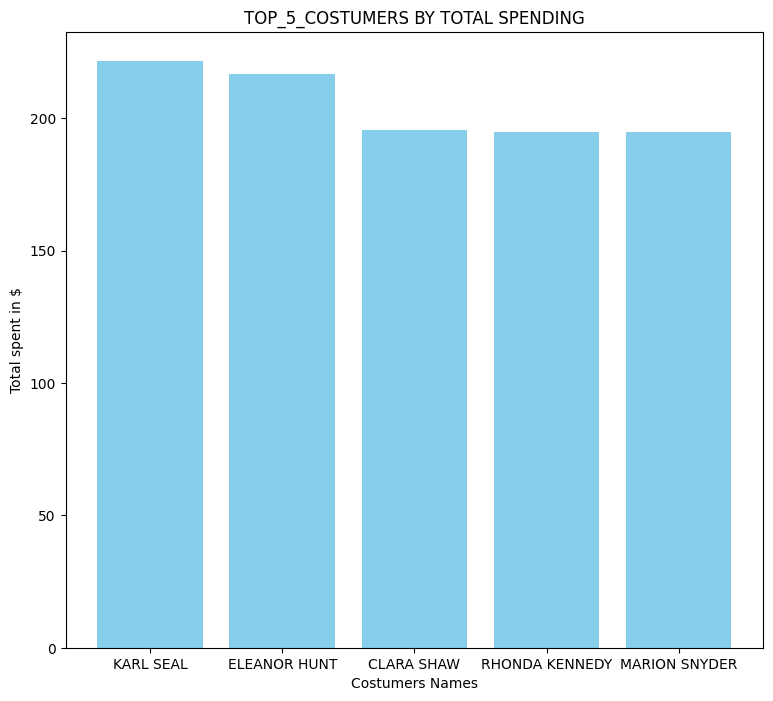

In [163]:
names = top_5_costumers["first_name"] + " " + top_5_costumers["last_name"]
spent = top_5_costumers["total_spent"] 

plt.figure(figsize=(9,8))
plt.bar(names,spent, color="skyblue")
plt.title("TOP_5_COSTUMERS BY TOTAL SPENDING")
plt.xlabel("Costumers Names")
plt.ylabel("Total spent in $")
plt.show()

In [164]:
# all income by category, joining multiple tables, and ordering by total income desc. 
income_by_category = duckdb.sql("""
    select 
        c.name as category,
        sum(p.amount) as total_income
    from category c 
    join film_category fc on c.category_id = fc.category_id          
    join film f on fc.film_id = f.film_id
    join inventory i on f.film_id = i.film_id
    join rental r on i.inventory_id = r.inventory_id
    join payment p on r.rental_id = p.rental_id
    group by c.name  
    order by total_income desc                            
                                
""").df()
income_by_category

,category,total_income
0,Sports,5314.21
1,Sci-Fi,4756.98
2,Animation,4656.30
3,Drama,4587.39
4,Comedy,4383.58
5,Action,4375.85
6,New,4351.62
7,Games,4281.33
8,Foreign,4270.67
9,Family,4226.07


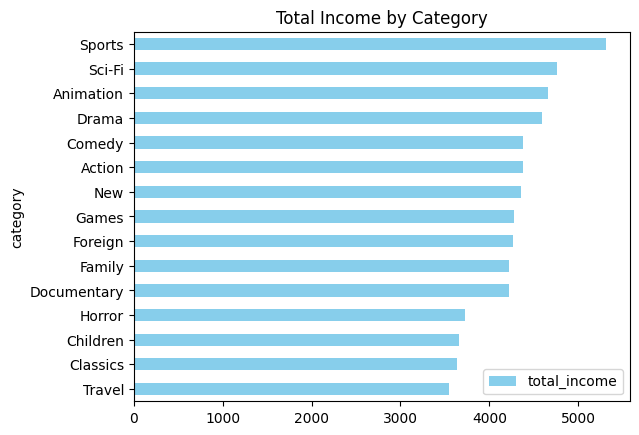

In [165]:
# following K.G exemple in lecture 
ax = income_by_category.head(15).plot(kind='barh',x="category",y="total_income",title = "Total Income by Category",color="skyblue")
ax.invert_yaxis()


### Extra plot 


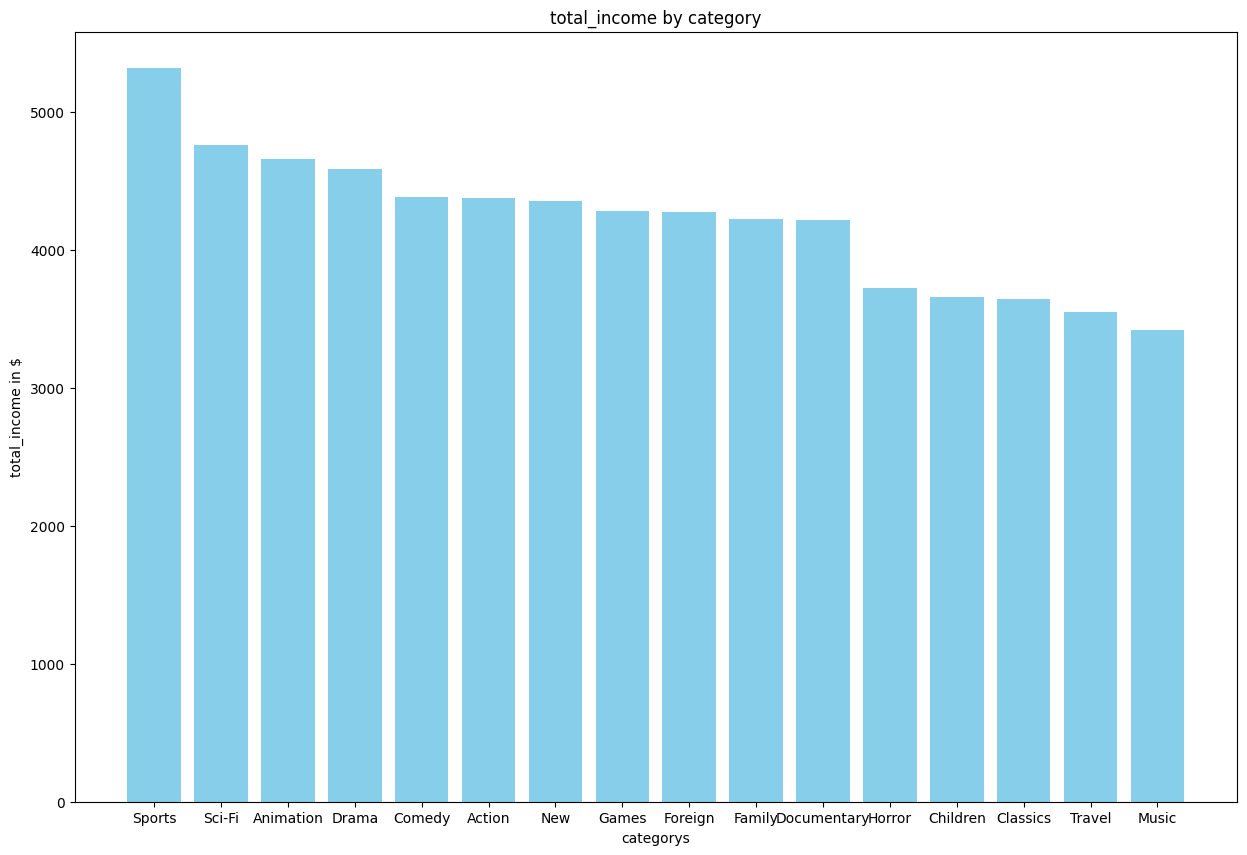

In [166]:
# A Classic vertical bar chart 
plt.figure(figsize=(15,10))
plt.bar(income_by_category["category"], income_by_category["total_income"], color ="skyblue")
plt.title ("total_income by category")
plt.xlabel("categorys")
plt.ylabel("total_income in $")  

plt.show()